# Mental Health Services during COVID-19

# Introduction
The world was in distress during the pandemic, and no one knew what to expect next. It was a time when people died from COVID-19, people were forced to stay home, and the world just seemed to be on pause. People who worked outside their homes were forced to stay at home, and depending on the person's profession, they may have lost their job because it couldn't be done virtually. With all these life changes, mental health in many became a reality that needed to be addressed. In my project, I want to know how the proportion of African American clients receiving mental health services (in community, hospital, or inpatient settings) changed from 2019 to 2021 during the COVID-19 pandemic.

# Import datasets from 2019-2021
The data came from https://www.samhsa.gov/data/data-we-collect/mh-cld-mental-health-client-level-data/datafiles/ but since the data files were in zip files, I have proivded the cvs files in the repository for ease.

In [ ]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_2019 = pd.read_csv("mhcld_puf_2019.csv")
df_2020 = pd.read_csv("mhcld_puf_2020.csv")
df_2021 = pd.read_csv("mhcld_puf_2021.csv")


# Filter by Race
This data is filter by race which is African American.

In [2]:
aa_2019 = df_2019[df_2019["RACE"] == 3].copy()
aa_2020 = df_2020[df_2020["RACE"] == 3].copy()
aa_2021 = df_2021[df_2021["RACE"] == 3].copy()

# Function to compute service rates
This function allows all the different service categories to display the percentage usage of services in each category by everyone during the COVID-19 years.  

In [3]:
def compute_service_rates(df, year):
    total = len(df)
    return {
        "Year": year,
        "Community Based Program": (df["CMPSERVICE"] == 1).sum() / total * 100,
        "State Hospital": (df["SPHSERVICE"] == 1).sum() / total * 100,
        "Inpatient Psychiatric": (df["OPISERVICE"] == 1).sum() / total * 100,
        "Residential": (df["RTCSERVICE"] == 1).sum() / total * 100,
    }

# Compute service rates for each year
In this code it computes the rate of service usage filtered by race.

In [4]:
rates_2019 = compute_service_rates(aa_2019, 2019)
rates_2020 = compute_service_rates(aa_2020, 2020)
rates_2021 = compute_service_rates(aa_2021, 2021)

df_rates = pd.DataFrame([rates_2019, rates_2020, rates_2021])

# Bar chart visualization function
In this function it allows for a bar chart to display the service usage rate by all races then by Afican Americans doing each year.

In [6]:
def plot_service_usage(df_2019, df_2020, df_2021, group_label="All Races"):
    rates_2019 = compute_service_rates(df_2019, 2019)
    rates_2020 = compute_service_rates(df_2020, 2020)
    rates_2021 = compute_service_rates(df_2021, 2021)

    df_rates = pd.DataFrame([rates_2019, rates_2020, rates_2021])
    service_types = ["Community Based Program", "State Hospital", "Inpatient Psychiatric", "Residential"]
    years = df_rates["Year"].tolist()
    x = np.arange(len(years))
    width = 0.2
    multiplier = 0

    fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')

    for service in service_types:
        offset = width * multiplier
        values = df_rates[service].tolist()
        rects = ax.bar(x + offset, values, width, label=service)
        ax.bar_label(rects, padding=3, fmt="%.1f%%")
        multiplier += 1

    ax.set_ylabel("Percentage of Clients Receiving Service (%)")
    ax.set_title(f"Mental Health Service Usage by {group_label} (2019–2021)")
    ax.set_xticks(x + width * (len(service_types) - 1) / 2, years)
    ax.legend(title="Service Type")
    ax.set_ylim(0, 100)
    plt.show()

# Bar Chart for Service Usage by All Races

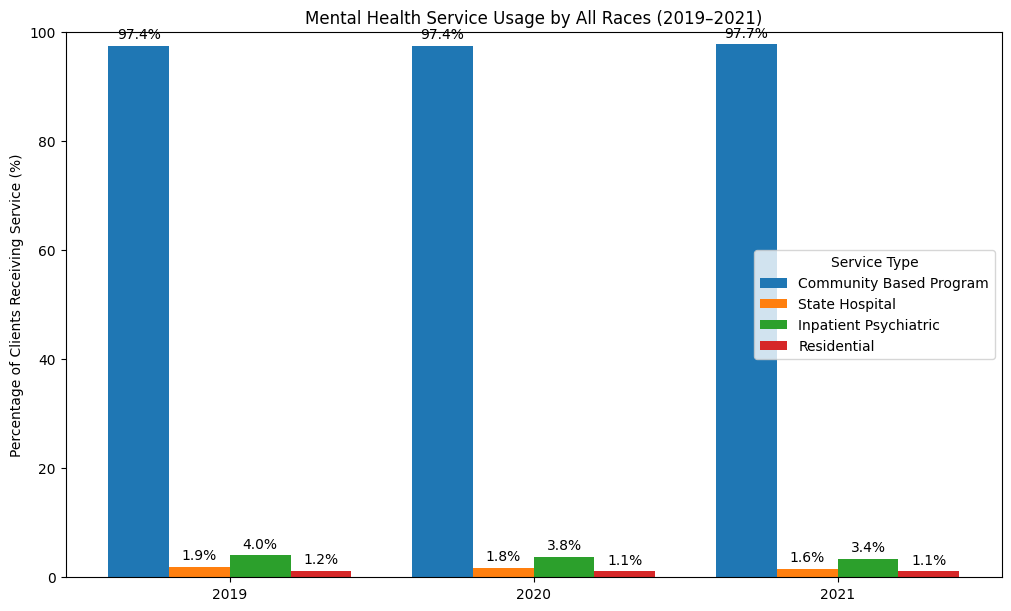

In [7]:
plot_service_usage(df_2019, df_2020, df_2021)

# Bar Chart for Service Usage by African Americans

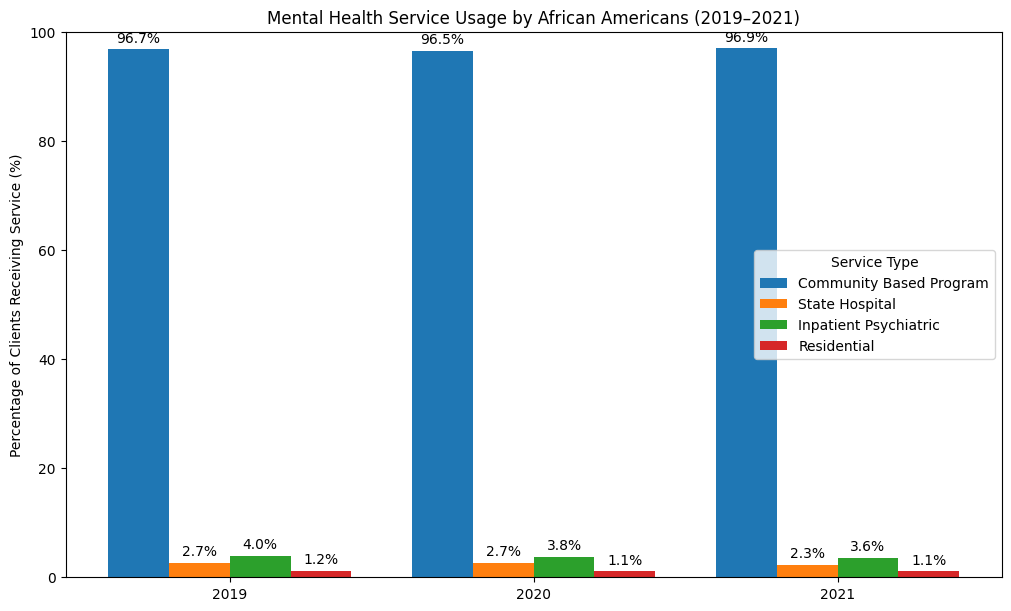

In [8]:
plot_service_usage(aa_2019, aa_2020, aa_2021, group_label="African Americans")